In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from IPython.display import display, HTML

warnings.filterwarnings("ignore")
sns.set_theme(context="talk", style="whitegrid", font_scale=0.85)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

print("✅ All libraries loaded.")

✅ All libraries loaded.


In [2]:
df = pd.read_csv(r'..\data\cleaned\cleaned_data.csv')

TARGET = "is_canceled"
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Shape: 82377 rows × 18 columns


In [3]:
df = df[
    (df["market_segment"] != "Undefined") &
    (df["distribution_channel"] != "Undefined")
]

In [4]:
# ── Global style ─────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family"        : "DejaVu Sans",
    "font.size"          : 10.5,
    "figure.facecolor"   : "white",
    "axes.facecolor"     : "white",
    "axes.titlesize"     : 13,
    "axes.titleweight"   : "regular",
    "axes.titlepad"      : 12,
    "axes.labelsize"     : 10,
    "axes.labelcolor"    : "#555",
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "axes.spines.left"   : False,
    "axes.spines.bottom" : True,
    "axes.grid"          : True,
    "axes.grid.axis"     : "x",
    "grid.color"         : "#EBEBEB",
    "grid.linewidth"     : 0.8,
    "xtick.labelsize"    : 9,
    "ytick.labelsize"    : 10.5,
    "xtick.color"        : "#777",
    "ytick.color"        : "#222",
    "xtick.bottom"       : False,
    "ytick.left"         : False,
    "figure.dpi"         : 130,
    "savefig.dpi"        : 130,
    "savefig.bbox"       : "tight",
    "legend.frameon"     : False,
    "legend.fontsize"    : 9,
})

# ── Palette ───────────────────────────────────────────────────────────────────
C_RED   = "#D94F4F"
C_AMBER = "#E8943A"
C_GREEN = "#4E9B4E"
C_BLUE  = "#3A7EC8"

def rate_color(r):
    if r > 0.50: return C_RED
    if r > 0.30: return C_AMBER
    return C_GREEN

def hbar(col, title, df=None, target=TARGET, figsize=(8, None)):
    if df is None:
        import __main__; df = __main__.df
    rates = df.groupby(col)[target].mean().sort_values()
    n = len(rates)
    h = figsize[1] or max(3.2, n * 0.58)
    fig, ax = plt.subplots(figsize=(figsize[0], h))

    colors = [rate_color(r) for r in rates.values]
    bars = ax.barh(range(n), rates.values, color=colors, height=0.52,
                   edgecolor="white", linewidth=0.6)

    ax.set_yticks(range(n))
    ax.set_yticklabels(rates.index, fontsize=10.5)

    for i, (bar, val) in enumerate(zip(bars, rates.values)):
        ax.text(val + 0.012, i, f"{val:.1%}",
                va="center", fontsize=10, color="#333", fontweight="regular")

    ax.set_xlim(0, min(rates.max() * 1.22, 1.05))
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_xlabel("Cancellation rate", labelpad=8)
    ax.set_title(title, loc="left", color="#111")
    ax.spines["bottom"].set_color("#D0D0D0")
    ax.tick_params(axis="x", colors="#999", length=3)

    legend_els = [
        mpatches.Patch(color=C_RED,   label="High  (> 50%)"),
        mpatches.Patch(color=C_AMBER, label="Medium (30–50%)"),
        mpatches.Patch(color=C_GREEN, label="Low  (< 30%)"),
    ]
    ax.legend(handles=legend_els, loc="lower right",
              fontsize=8.5, handlelength=1, handleheight=0.9,
              labelspacing=0.3, borderpad=0.6,
              bbox_to_anchor=(1.0, 0.0))

    plt.tight_layout(pad=1.4)
    plt.show()

print("✅ Chart style loaded — ready to plot.")

✅ Chart style loaded — ready to plot.


### 0. Dataset Overview

This notebook explores a hotel booking dataset containing **82,377 reservations** collected across two property types — *City Hotel* and *Resort Hotel* — spanning the years **2015 to 2017**. Each record represents a single booking and captures a wide range of guest behaviour, booking logistics, and commercial attributes at the time of reservation.

The dataset is structured around **18 features**: 11 numerical and 6 categorical, alongside the binary target variable `is_canceled` which indicates whether a booking was ultimately cancelled. Crucially, the data arrives in a clean state — **no missing values and no duplicate records** — meaning the focus of this section is purely exploratory: understanding distributions, spotting anomalies, and building intuition before any modelling begins.

The sections below walk through three lenses:
- **0.1 — Data structure & schema:** column types, null counts, and a sample of raw values.
- **0.2 — Numerical statistics:** descriptive summaries of continuous and integer features.
- **0.3 — Categorical profiles:** value counts and share breakdowns for all categorical fields.

A summary table and key observations close this section before moving into target-variable and feature-level analysis.


In [24]:
# ── 0.1 Shape, dtypes & sample rows ─────────────────────────────────────────
from IPython.display import display, HTML

print(f"📐 Shape : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"🎯 Target : '{TARGET}'\n")

# Dtype summary table
dtype_df = pd.DataFrame({
    "Column"      : df.dtypes.index,
    "Dtype"       : df.dtypes.values.astype(str),
    "Non-Null"    : df.notnull().sum().values,
    "Null"        : df.isnull().sum().values,
    "Unique"      : [df[c].nunique() for c in df.columns],
    "Sample"      : [str(df[c].iloc[0]) for c in df.columns],
}).reset_index(drop=True)

print("── Column overview ──────────────────────────────────────────────────────")
display(dtype_df)
print(f"\n✅ Total nulls  : {df.isnull().sum().sum()}")
print(f"✅ Duplicates   : {df.duplicated().sum()}")


📐 Shape : 82,372 rows  ×  18 columns
🎯 Target : 'is_canceled'

── Column overview ──────────────────────────────────────────────────────


,Column,Dtype,Non-Null,Null,Unique,Sample
0,lead_time,int64,82372,0,479,342
1,required_car_parking_spaces,int64,82372,0,5,0
2,total_of_special_requests,int64,82372,0,6,0
3,previous_cancellations,int64,82372,0,15,0
4,previous_bookings_not_canceled,int64,82372,0,73,0
5,adr,float64,82372,0,8865,0.0
6,adults,int64,82372,0,14,2
7,children,int64,82372,0,5,0
8,babies,int64,82372,0,5,0
9,deposit_type,str,82372,0,3,No Deposit



✅ Total nulls  : 0
✅ Duplicates   : 0


In [25]:
# ── 0.2 Descriptive statistics — numerical features ─────────────────────────
NUM_COLS = df.select_dtypes(include="number").columns.drop(TARGET).tolist()
CAT_COLS = df.select_dtypes(include="object").columns.tolist()

print(f"Numerical features ({len(NUM_COLS)}): {NUM_COLS}")
print(f"Categorical features ({len(CAT_COLS)}): {CAT_COLS}\n")

display(df[NUM_COLS].describe().round(2))


Numerical features (11): ['lead_time', 'required_car_parking_spaces', 'total_of_special_requests', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'adults', 'children', 'babies', 'arrival_date_year', 'arrival_date_day_of_month']
Categorical features (6): ['deposit_type', 'market_segment', 'distribution_channel', 'customer_type', 'hotel', 'arrival_date_month']



,lead_time,required_car_parking_spaces,total_of_special_requests,previous_cancellations,previous_bookings_not_canceled,adr,adults,children,babies,arrival_date_year,arrival_date_day_of_month
count,82372.00,82372.00,82372.00,82372.00,82372.00,82372.00,82372.00,82372.00,82372.00,82372.00,82372.00
mean,78.44,0.09,0.72,0.03,0.19,107.56,1.89,0.15,0.01,2016.22,15.80
std,84.26,0.29,0.84,0.38,1.78,55.57,0.62,0.47,0.12,0.68,8.85
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2015.00,1.00
25%,11.00,0.00,0.00,0.00,0.00,73.00,2.00,0.00,0.00,2016.00,8.00
50%,48.00,0.00,1.00,0.00,0.00,99.00,2.00,0.00,0.00,2016.00,16.00
75%,123.00,0.00,1.00,0.00,0.00,135.15,2.00,0.00,0.00,2017.00,24.00
max,737.00,8.00,5.00,26.00,72.00,5400.00,55.00,10.00,10.00,2017.00,31.00


In [26]:
# ── 0.3 Categorical feature value counts ────────────────────────────────────
for col in CAT_COLS:
    vc = df[col].value_counts()
    pct = (vc / len(df) * 100).round(1)
    summary = pd.DataFrame({"Count": vc, "Pct (%)": pct})
    print(f"\n── {col} ──────────────────────────────")
    display(summary)



── deposit_type ──────────────────────────────


,Count,Pct (%)
deposit_type,,
No Deposit,81325,98.7
Non Refund,978,1.2
Refundable,69,0.1



── market_segment ──────────────────────────────


,Count,Pct (%)
market_segment,,
Online TA,50363,61.1
Offline TA/TO,12552,15.2
Direct,11393,13.8
Corporate,3809,4.6
Groups,3397,4.1
Complementary,668,0.8
Aviation,190,0.2



── distribution_channel ──────────────────────────────


...

,Count,Pct (%)
customer_type,,
Transient,70077,85.1
Transient-Party,8743,10.6
Contract,3026,3.7
Group,526,0.6



── hotel ──────────────────────────────


,Count,Pct (%)
hotel,,
City Hotel,49894,60.6
Resort Hotel,32478,39.4



── arrival_date_month ──────────────────────────────


,Count,Pct (%)
arrival_date_month,,
August,10884,13.2
July,9751,11.8
May,7838,9.5
April,7492,9.1
June,7354,8.9
March,7086,8.6
October,6284,7.6
September,6023,7.3
February,5790,7.0


**Dataset Summary**

| Property | Value |
|---|---|
| **Total rows** | 82,377 |
| **Total columns** | 18 |
| **Target variable** | `is_canceled` (binary: 0 = kept, 1 = cancelled) |
| **Numerical features** | 11 |
| **Categorical features** | 6 |
| **Missing values** | **0** |
| **Duplicates** | **0** |

The dataset is clean and complete — no imputation or deduplication is required. It covers hotel bookings from **2015–2017** across **City Hotel** and **Resort Hotel** types.


### 1.1 Feature Distributions

Overview of how each feature is distributed across the dataset — before any target conditioning.

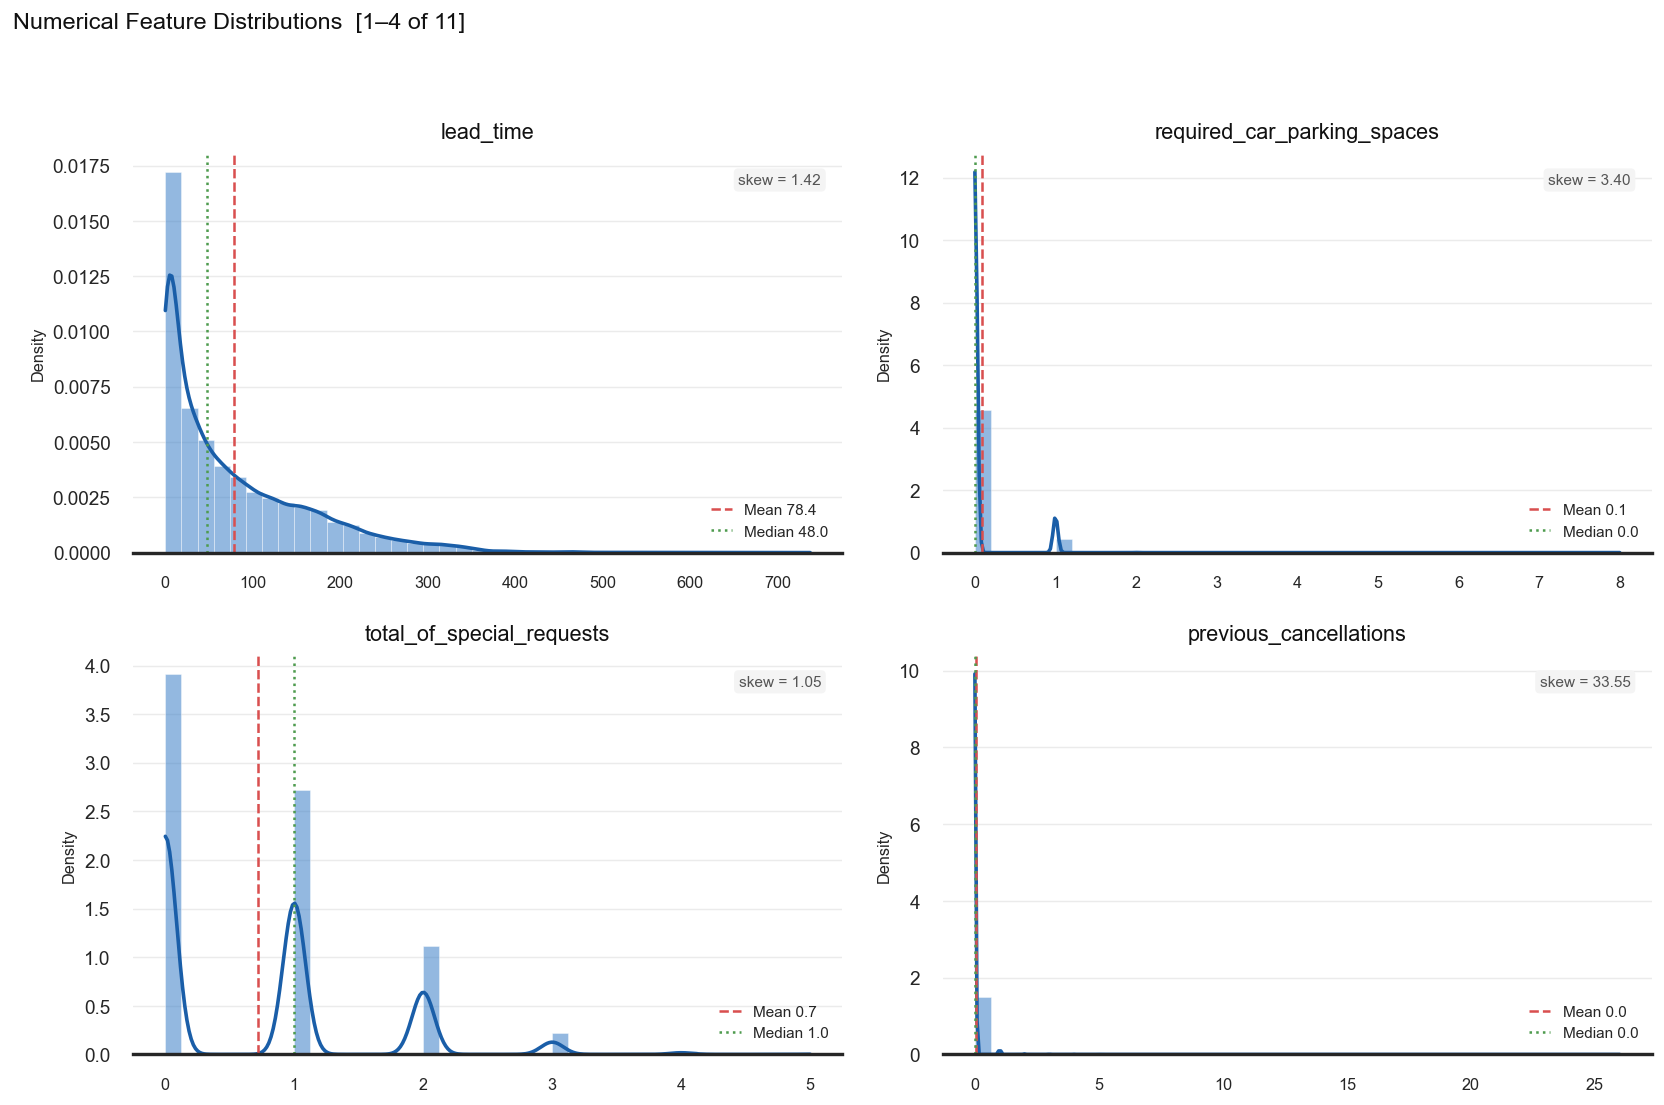

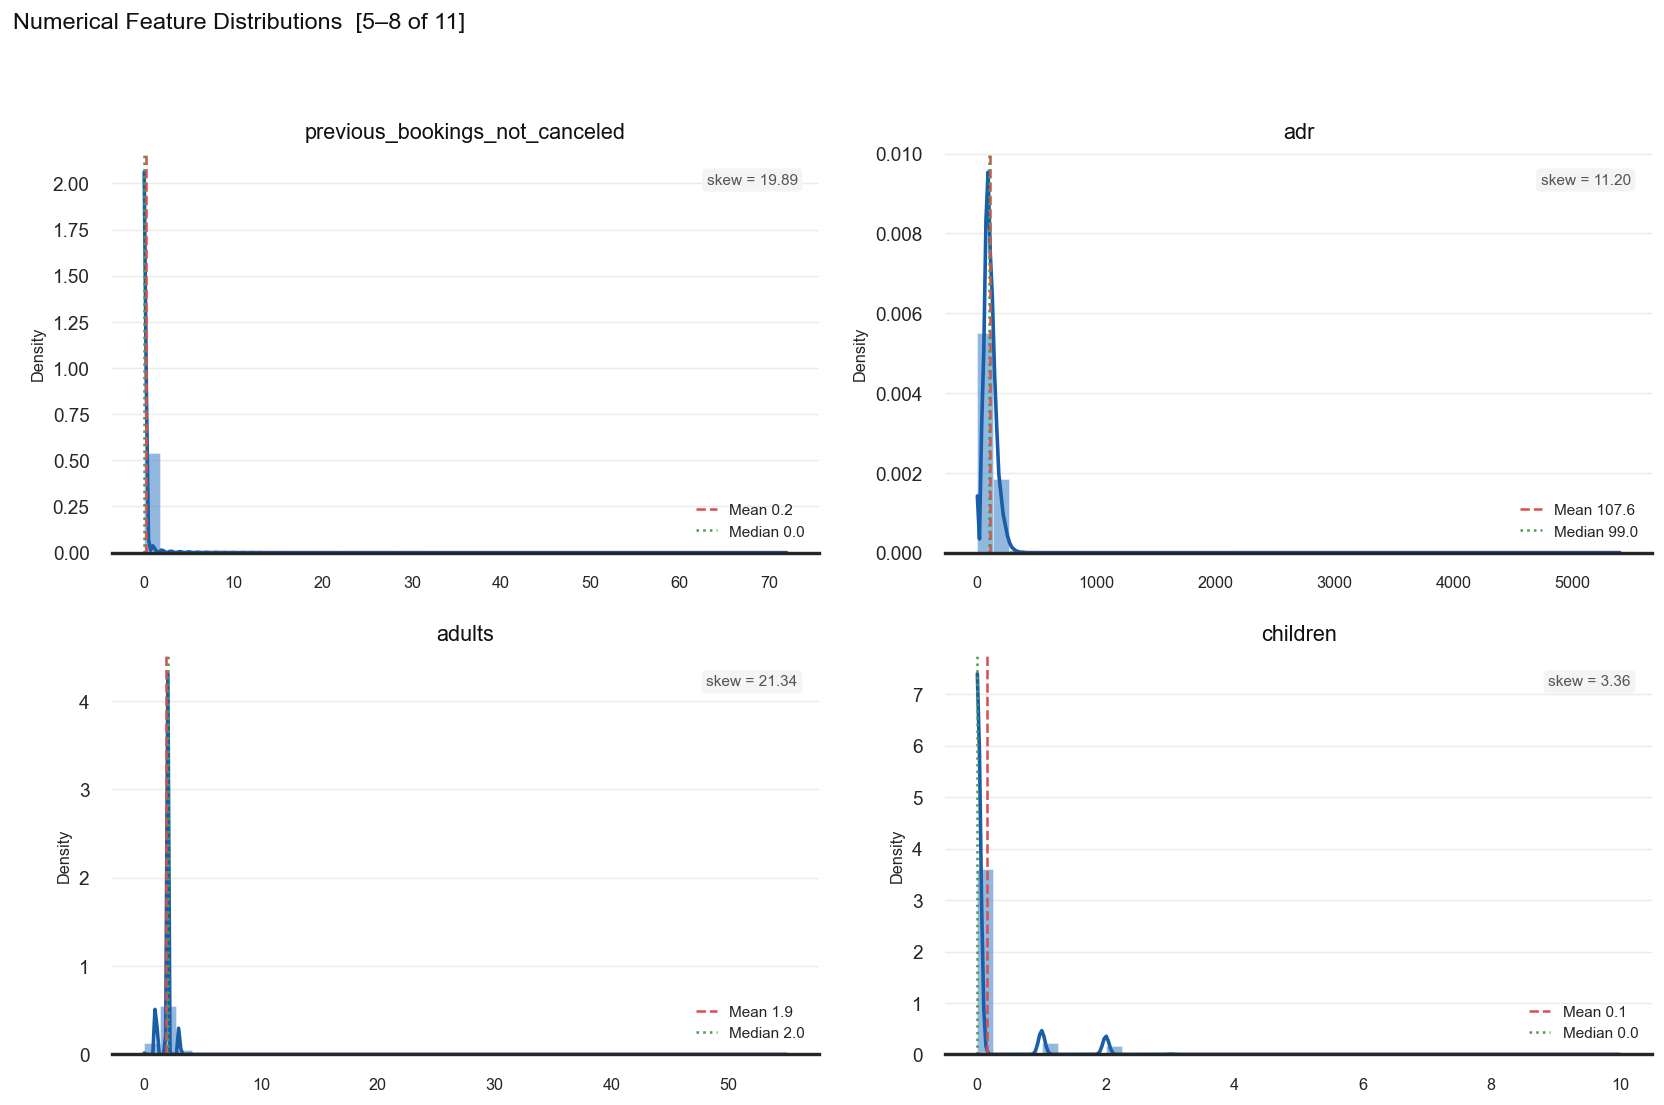

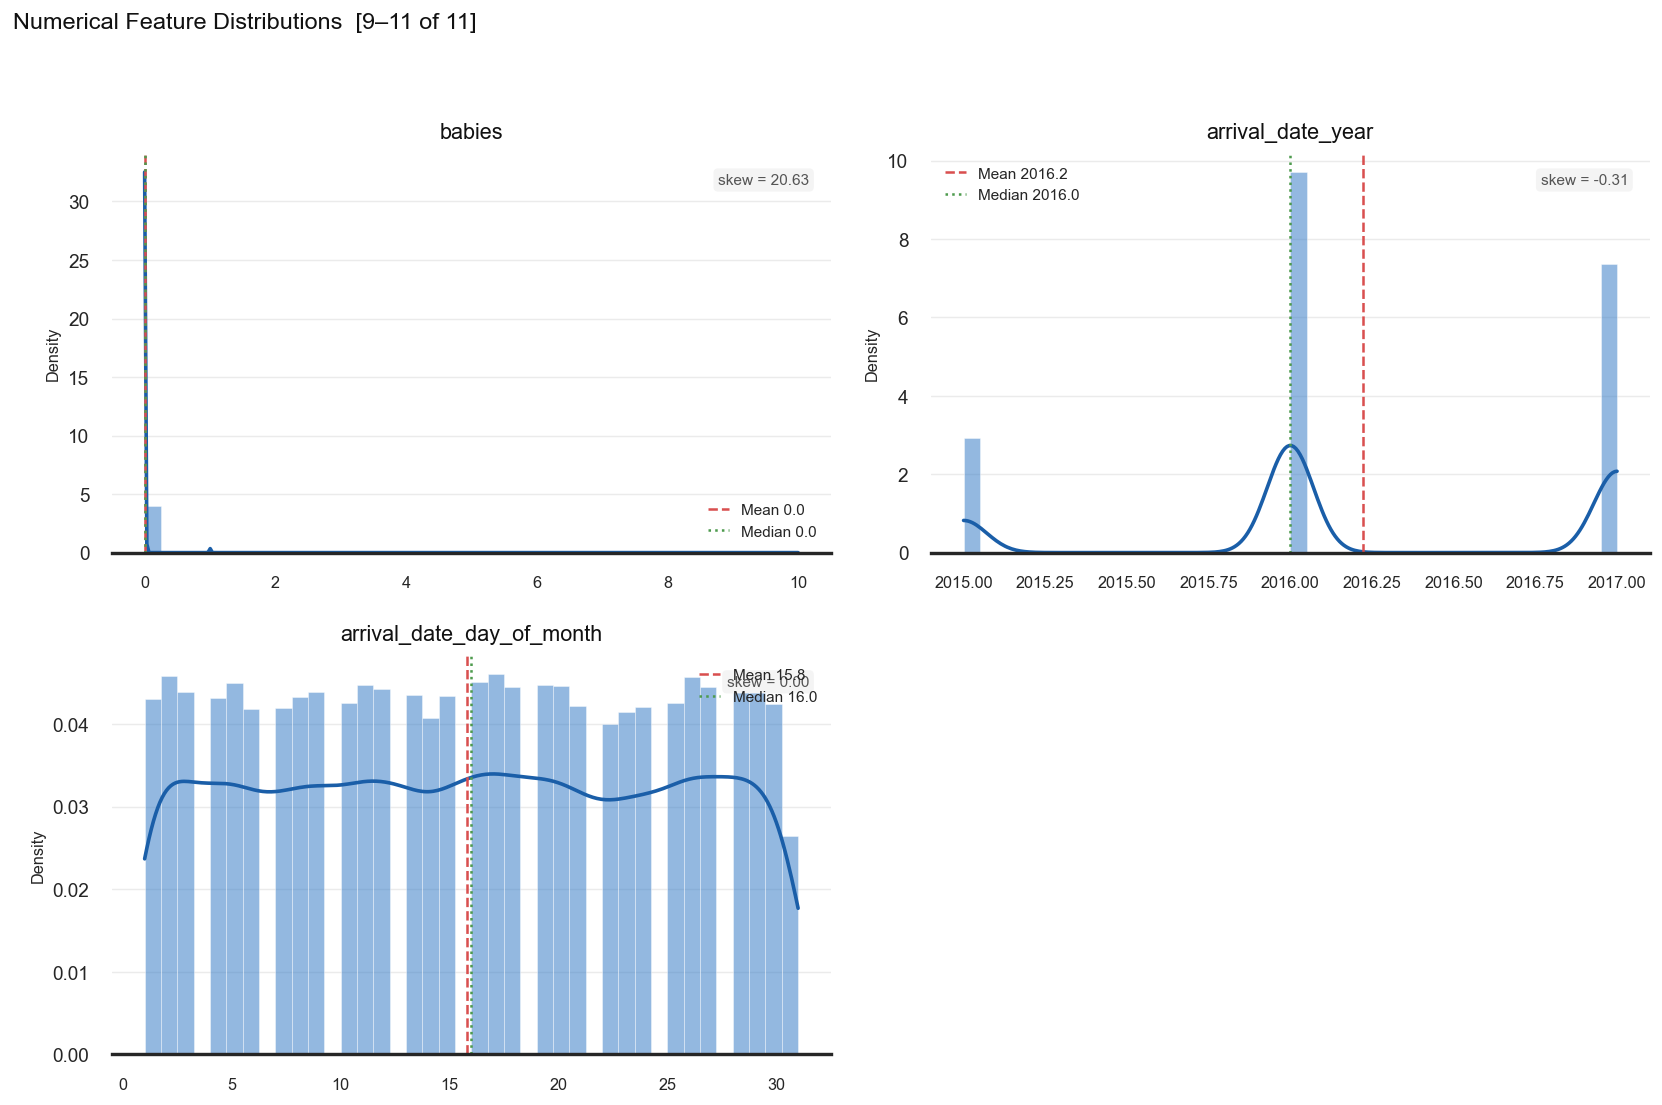

In [8]:
# ── Numerical features: histogram + KDE  (≤4 per figure) ───────────────────
sns.set_style('white')

CHUNK_SIZE = 4   # max features per figure
chunks = [NUM_COLS[i:i+CHUNK_SIZE] for i in range(0, len(NUM_COLS), CHUNK_SIZE)]

for chunk_idx, cols in enumerate(chunks):
    n = len(cols)
    n_cols_grid = min(n, 2)
    n_rows_grid = -(-n // n_cols_grid)
    fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(13, n_rows_grid * 4.2))
    axes_flat = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(cols):
        ax = axes_flat[i]

        # Histogram + KDE
        data = df[col].dropna()
        ax.hist(data, bins=40, color=C_BLUE, alpha=0.55, edgecolor='white',
                linewidth=0.4, density=True, label='_nolegend_')
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(data, bw_method='scott')
        xs  = np.linspace(data.min(), data.max(), 300)
        ax.plot(xs, kde(xs), color='#1A5EA8', linewidth=2)

        mean_v   = data.mean()
        median_v = data.median()
        ax.axvline(mean_v,   color=C_RED,   linestyle='--', linewidth=1.4,
                   label=f'Mean {mean_v:.1f}')
        ax.axvline(median_v, color=C_GREEN, linestyle=':',  linewidth=1.4,
                   label=f'Median {median_v:.1f}')

        skew = data.skew()
        ax.text(0.97, 0.95, f'skew = {skew:.2f}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=8.5, color='#555',
                bbox=dict(boxstyle='round,pad=0.3', fc='#F4F4F4', ec='none'))

        ax.set_title(col, fontsize=12, fontweight='regular', color='#111', pad=8)
        ax.set_xlabel('')
        ax.set_ylabel('Density', fontsize=9)
        ax.legend(fontsize=8.5, handlelength=1.4, frameon=False)
        ax.grid(axis='y', color='#EBEBEB'); ax.set_axisbelow(True)
        ax.spines[['top','right','left']].set_visible(False)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    start = chunk_idx * CHUNK_SIZE + 1
    end   = start + n - 1
    fig.suptitle(f'Numerical Feature Distributions  [{start}–{end} of {len(NUM_COLS)}]',
                 fontsize=13, x=0.01, ha='left', color='#111', y=1.02)
    plt.tight_layout(pad=1.8)
    plt.show()


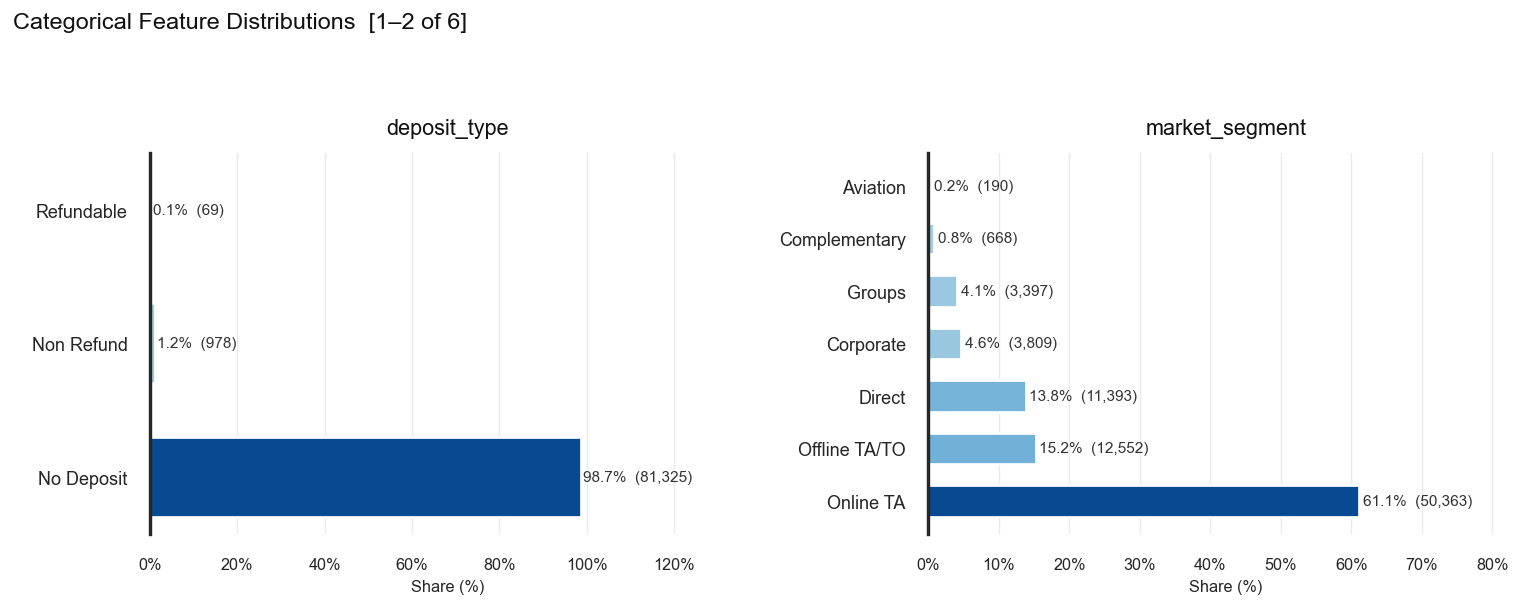

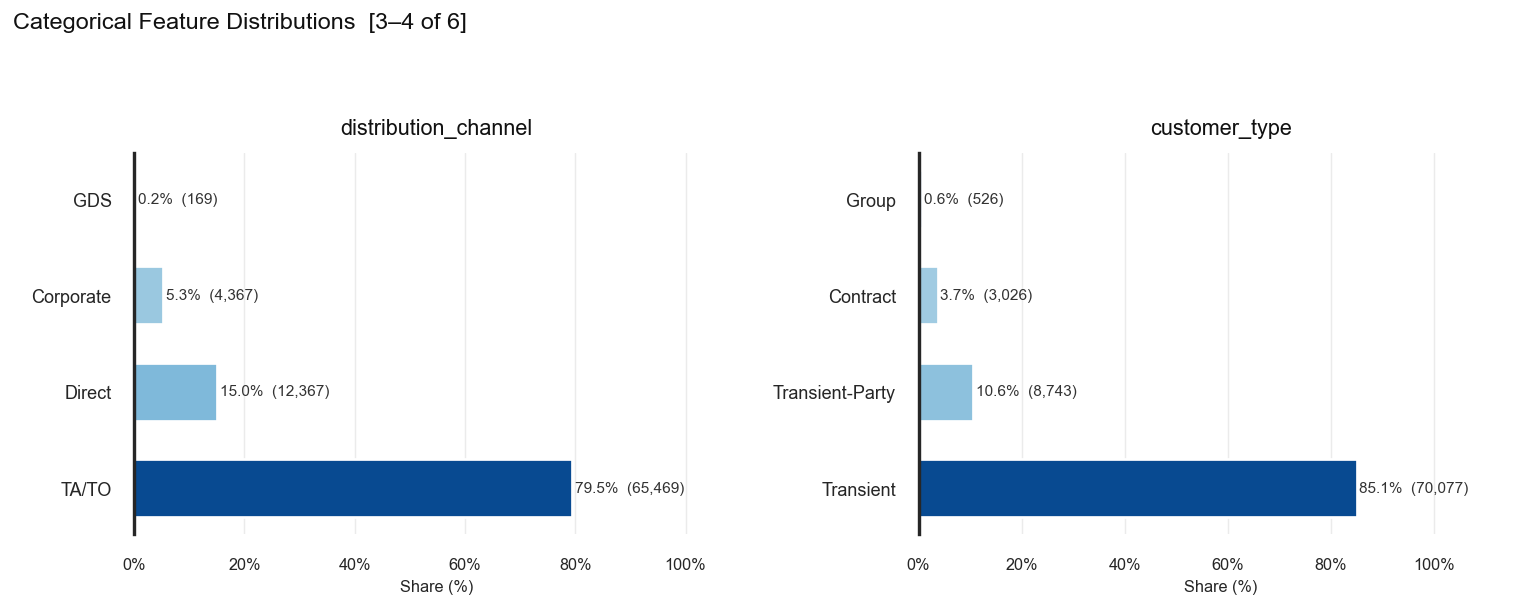

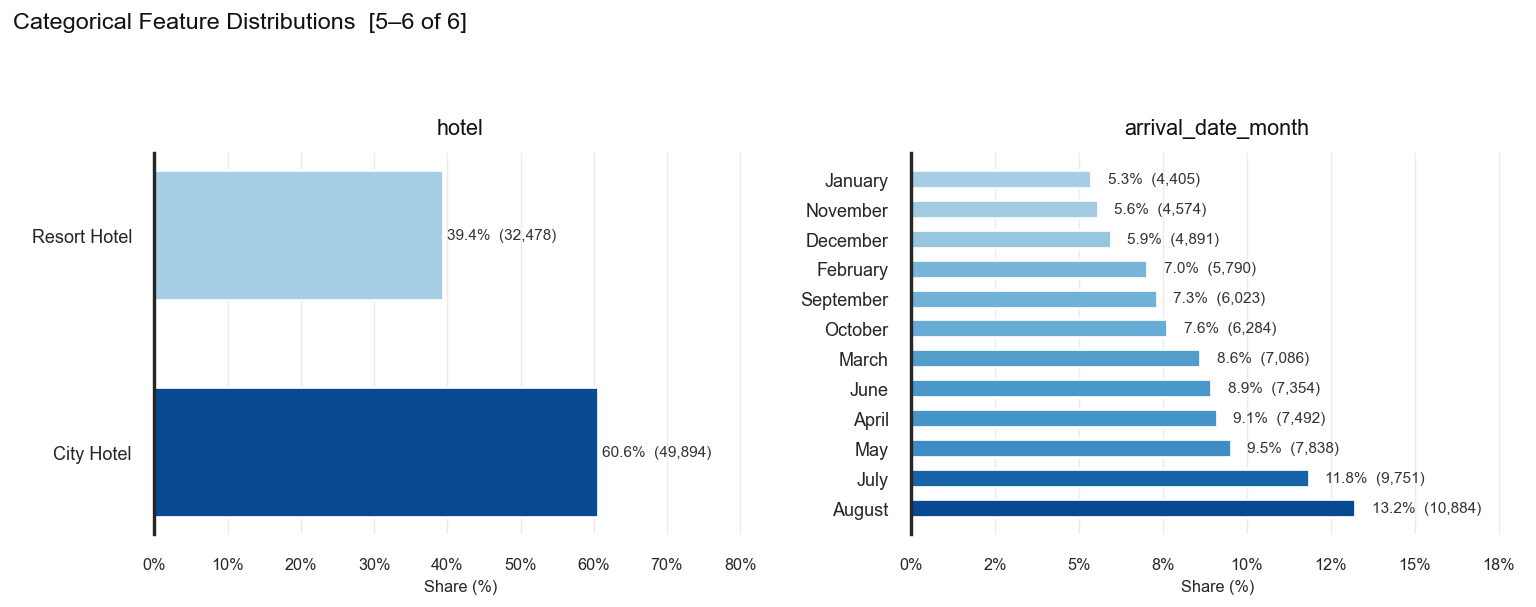

In [9]:
# ── Categorical features: individual bar charts (2 per figure) ──────────────
CAT_PAIRS = [CAT_COLS[i:i+2] for i in range(0, len(CAT_COLS), 2)]

for pair_idx, cols in enumerate(CAT_PAIRS):
    fig, axes = plt.subplots(1, len(cols), figsize=(12, 4.6))
    if len(cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        vc  = df[col].value_counts()
        pct = vc / len(df) * 100

        # Colour gradient by share
        norm   = plt.Normalize(pct.min(), pct.max())
        colors = [plt.cm.Blues(0.35 + 0.55 * norm(v)) for v in pct.values]

        bars = ax.barh(range(len(vc)), pct.values,
                       color=colors, edgecolor='white', height=0.60)
        ax.set_yticks(range(len(vc)))
        ax.set_yticklabels(vc.index, fontsize=10)
        ax.set_xlabel('Share (%)', fontsize=9)
        ax.set_title(col, fontsize=12, color='#111', fontweight='regular', pad=10)

        for bar, val, cnt in zip(bars, pct.values, vc.values):
            ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                    f'{val:.1f}%  ({cnt:,})',
                    va='center', fontsize=8.5, color='#333')

        ax.set_xlim(0, pct.max() * 1.38)
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
        ax.grid(axis='x', color='#EBEBEB'); ax.set_axisbelow(True)
        ax.spines[['top','right','bottom']].set_visible(False)

    start = pair_idx * 2 + 1
    end   = start + len(cols) - 1
    fig.suptitle(f'Categorical Feature Distributions  [{start}–{end} of {len(CAT_COLS)}]',
                 fontsize=13, x=0.01, ha='left', color='#111', y=1.03)
    plt.tight_layout(pad=1.8)
    plt.show()


**Insight — Feature Distributions**

**Numerical:**
- **`lead_time`** is heavily right-skewed (mean 78 days, max 737 days) — most bookings are made within 3 months but a long tail of far-advance bookings exists.
- **`adr`** (average daily rate) peaks around €99 with a long tail up to €5,400 — extreme values may be data quirks.
- **`previous_cancellations`** and **`previous_bookings_not_canceled`** are near-zero for the vast majority — most guests are first-timers.
- **`total_of_special_requests`** is discrete and concentrated at 0–2, hinting at a strong commitment signal.

**Categorical:**
- **`market_segment`**: Online TA dominates at ~61% of bookings — the single most important segment to watch.
- **`distribution_channel`**: TA/TO accounts for ~80% of all bookings.
- **`customer_type`**: Transient guests make up ~85% — the most volatile group.
- **`deposit_type`**: >98% of bookings are "No Deposit", making the `Non Refund` category a rare but extreme outlier.
- **`hotel`**: City Hotel (60%) vs Resort Hotel (40%) — a meaningful split worth modelling separately.


### 1.2 Outlier Analysis

Outliers are detected using the **IQR (Interquartile Range)** method:  
any value below `Q1 − 1.5 × IQR` or above `Q3 + 1.5 × IQR` is flagged as an outlier.

In [10]:
# ── IQR outlier summary table ────────────────────────────────────────────────
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outlier_rows = []
for col in NUM_COLS:
    lo, hi = iqr_bounds(df[col])
    mask   = (df[col] < lo) | (df[col] > hi)
    n_out  = mask.sum()
    pct    = n_out / len(df) * 100
    outlier_rows.append({
        "Feature"      : col,
        "Q1"           : round(df[col].quantile(0.25), 2),
        "Q3"           : round(df[col].quantile(0.75), 2),
        "IQR"          : round(df[col].quantile(0.75) - df[col].quantile(0.25), 2),
        "Lower fence"  : round(lo, 2),
        "Upper fence"  : round(hi, 2),
        "# Outliers"   : int(n_out),
        "% Outliers"   : f"{pct:.2f}%",
        "Severity"     : "🔴 High" if pct > 5 else ("🟠 Medium" if pct > 1 else "🟢 Low"),
    })

outlier_df = pd.DataFrame(outlier_rows)
display(outlier_df)
print(f"\nTotal outlier records (any column): "
      f"{df[[c for c in NUM_COLS]].apply(lambda s: (s < iqr_bounds(s)[0]) | (s > iqr_bounds(s)[1])).any(axis=1).sum():,}")


,Feature,Q1,Q3,IQR,Lower fence,Upper fence,# Outliers,% Outliers,Severity
0,lead_time,11.0,123.00,112.00,-157.00,291.00,2218,2.69%,🟠 Medium
1,required_car_parking_spaces,0.0,0.00,0.00,0.00,0.00,7216,8.76%,🔴 High
2,total_of_special_requests,0.0,1.00,1.00,-1.50,2.50,2615,3.17%,🟠 Medium
3,previous_cancellations,0.0,0.00,0.00,0.00,0.00,1637,1.99%,🟠 Medium
4,previous_bookings_not_canceled,0.0,0.00,0.00,0.00,0.00,3508,4.26%,🟠 Medium
5,adr,73.0,135.15,62.15,-20.23,228.38,2419,2.94%,🟠 Medium
6,adults,2.0,2.00,0.00,2.00,2.00,20782,25.23%,🔴 High
7,children,0.0,0.00,0.00,0.00,0.00,8288,10.06%,🔴 High
8,babies,0.0,0.00,0.00,0.00,0.00,909,1.10%,🟠 Medium
9,arrival_date_year,2016.0,2017.00,1.00,2014.50,2018.50,0,0.00%,🟢 Low



Total outlier records (any column): 37,796


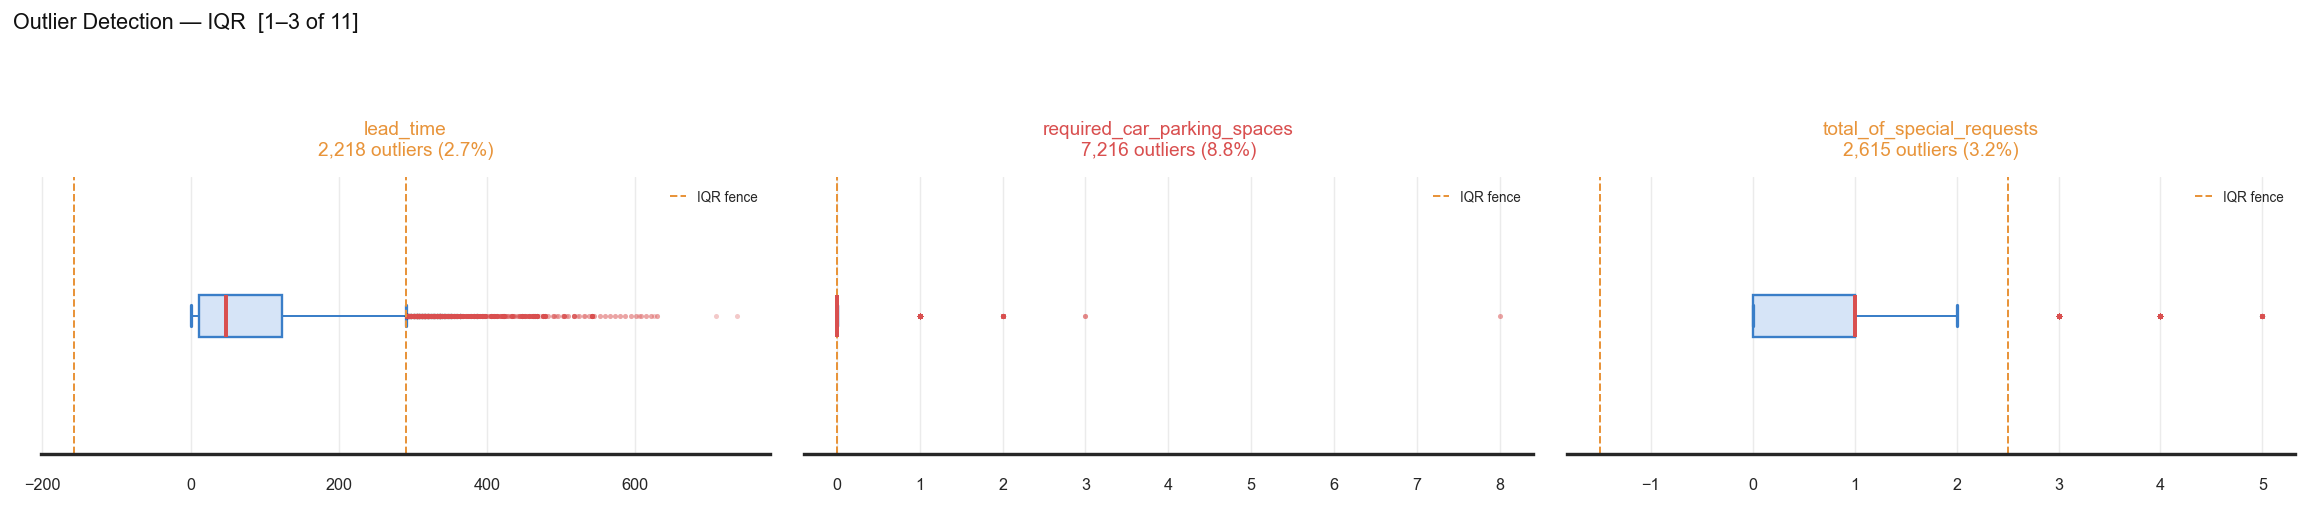

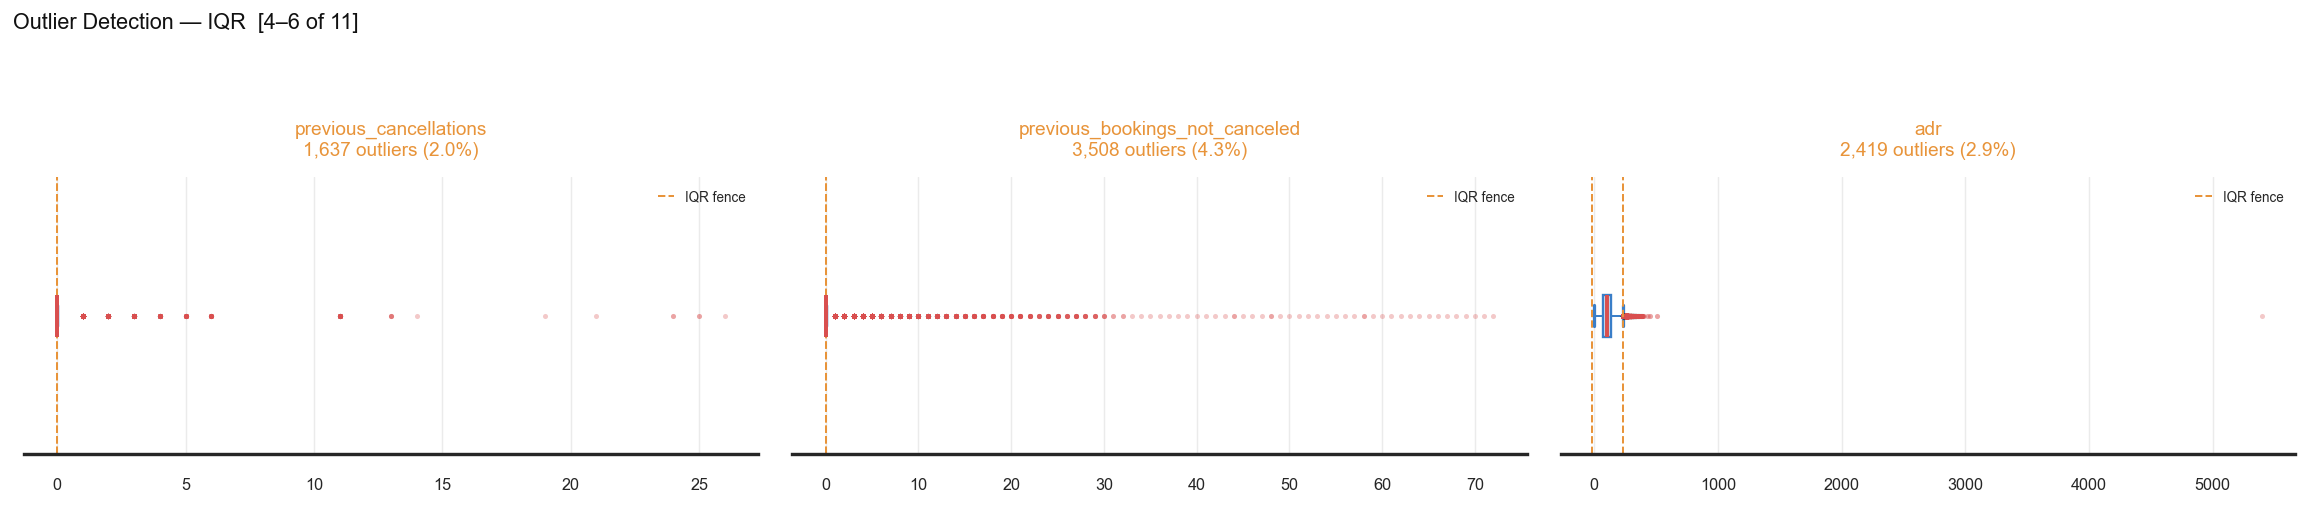

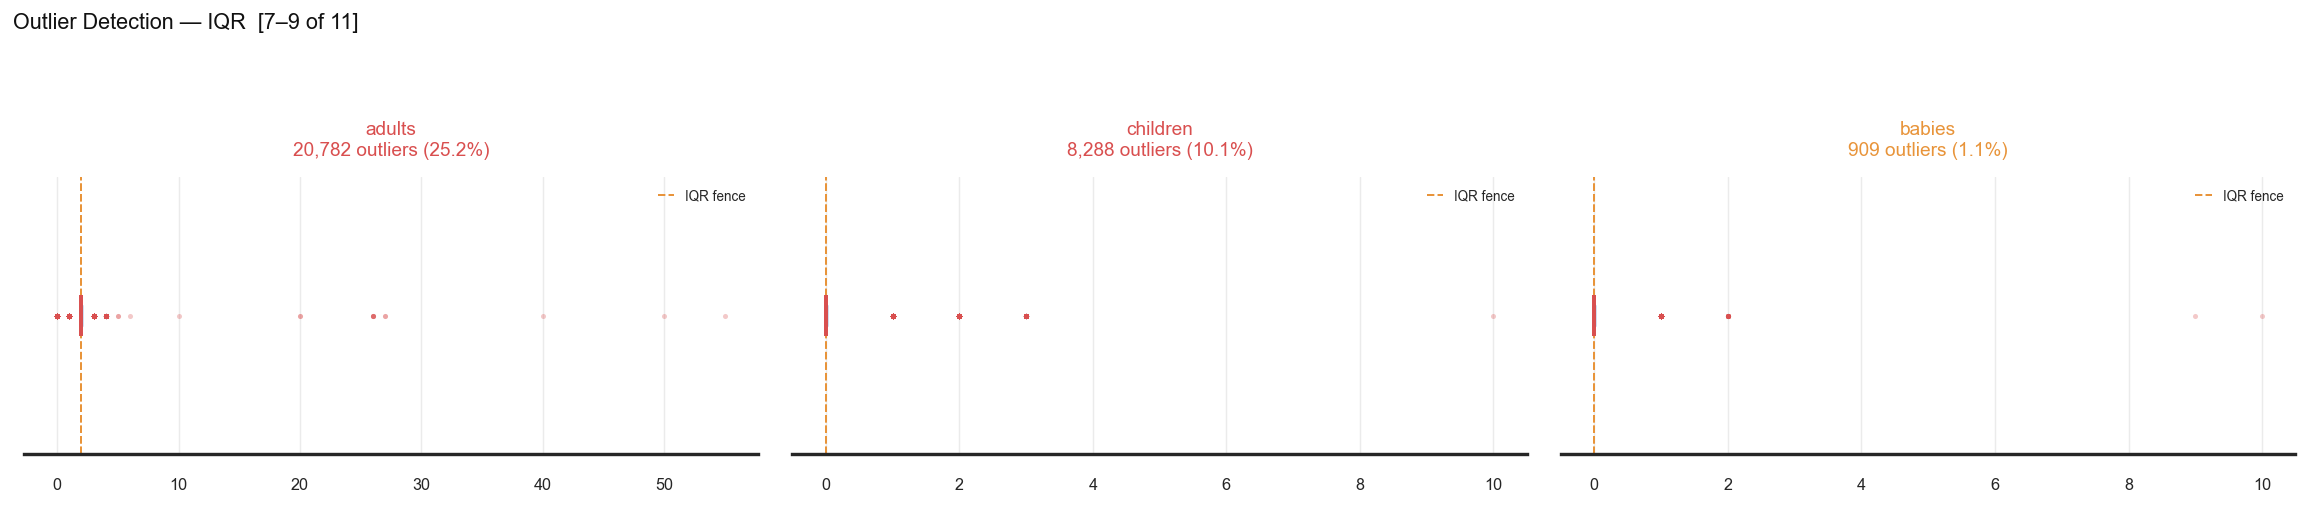

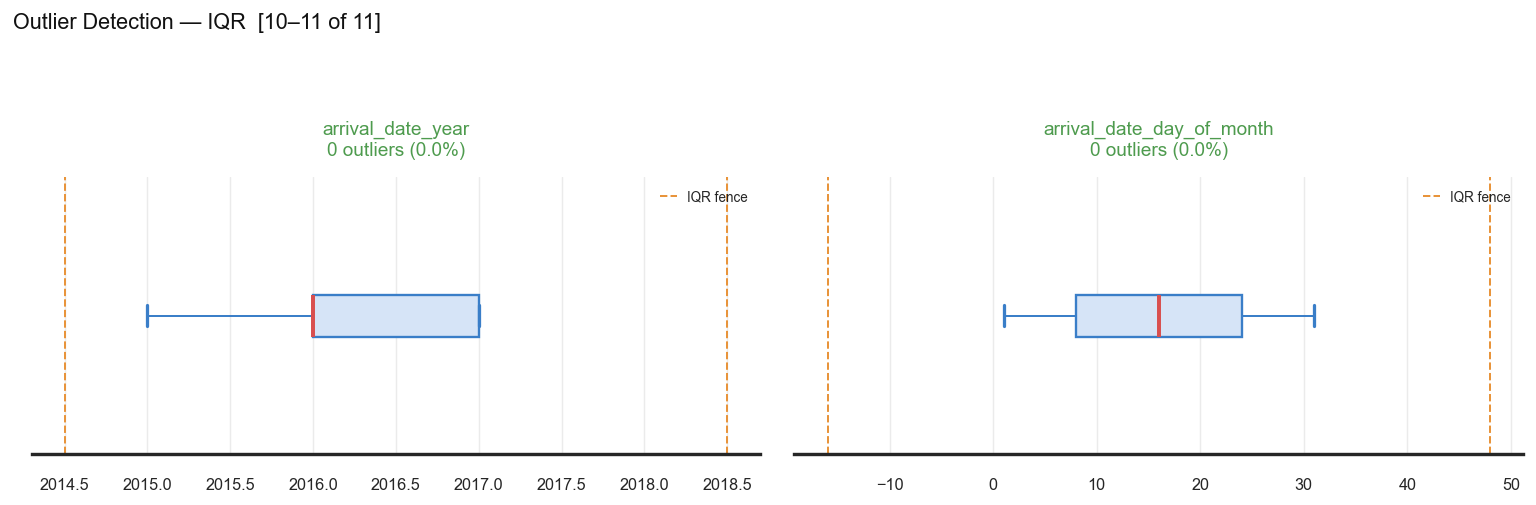

In [11]:
# ── Boxplots — 3 per figure, cleaner layout ─────────────────────────────────
CHUNK_SIZE = 3
chunks = [NUM_COLS[i:i+CHUNK_SIZE] for i in range(0, len(NUM_COLS), CHUNK_SIZE)]

FLIER_PROPS = dict(marker='o', markersize=2.8, alpha=0.30,
                   markerfacecolor=C_RED, markeredgecolor='none')

for chunk_idx, cols in enumerate(chunks):
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 3.8))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        ax.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                   flierprops=FLIER_PROPS,
                   medianprops=dict(color=C_RED, linewidth=2.2),
                   boxprops=dict(facecolor='#D6E4F7', edgecolor='#3A7EC8', linewidth=1.3),
                   whiskerprops=dict(color='#3A7EC8', linewidth=1.1),
                   capprops=dict(color='#3A7EC8', linewidth=1.8))

        lo, hi = iqr_bounds(df[col])
        ax.axvline(lo, color=C_AMBER, linestyle='--', linewidth=1.1, label='IQR fence')
        ax.axvline(hi, color=C_AMBER, linestyle='--', linewidth=1.1)

        n_out = ((df[col] < lo) | (df[col] > hi)).sum()
        pct   = n_out / len(df) * 100
        color = C_RED if pct > 5 else (C_AMBER if pct > 1 else C_GREEN)

        ax.set_title(f'{col}\n{n_out:,} outliers ({pct:.1f}%)',
                     fontsize=10.5, color=color, fontweight='regular')
        ax.set_yticks([])
        ax.grid(axis='x', color='#EBEBEB'); ax.set_axisbelow(True)
        ax.spines[['top','right','left']].set_visible(False)
        ax.legend(fontsize=7.5, handlelength=1.2, loc='upper right')

    start = chunk_idx * CHUNK_SIZE + 1
    end   = start + n - 1
    fig.suptitle(f'Outlier Detection — IQR  [{start}–{end} of {len(NUM_COLS)}]',
                 fontsize=12, x=0.01, ha='left', color='#111', y=1.04)
    plt.tight_layout(pad=1.8)
    plt.show()


In [12]:
# ── Outlier impact on cancellation rate ─────────────────────────────────────
print("Cancellation rate — Outliers vs Non-outliers\n")
print(f"{'Feature':<35} {'Outlier Cancel%':>16} {'Normal Cancel%':>15} {'Δ':>8}")
print("─" * 76)

for col in NUM_COLS:
    lo, hi = iqr_bounds(df[col])
    is_out = (df[col] < lo) | (df[col] > hi)
    r_out  = df.loc[is_out,  TARGET].mean() if is_out.sum() > 0 else float("nan")
    r_norm = df.loc[~is_out, TARGET].mean()
    delta  = r_out - r_norm if not pd.isna(r_out) else float("nan")
    flag   = "⚠️ " if abs(delta) > 0.05 and not pd.isna(delta) else "  "
    print(f"{flag}{col:<33} "
          f"{r_out*100:>14.1f}%  {r_norm*100:>14.1f}%  {delta*100:>+7.1f}pp")


Cancellation rate — Outliers vs Non-outliers

Feature                              Outlier Cancel%  Normal Cancel%        Δ
────────────────────────────────────────────────────────────────────────────
⚠️ lead_time                                   51.1%            27.8%    +23.3pp
⚠️ required_car_parking_spaces                  0.0%            31.1%    -31.1pp
⚠️ total_of_special_requests                   16.4%            28.8%    -12.4pp
⚠️ previous_cancellations                      67.1%            27.6%    +39.5pp
⚠️ previous_bookings_not_canceled               5.0%            29.4%    -24.4pp
⚠️ adr                                         38.9%            28.1%    +10.8pp
  adults                                      24.9%            29.6%     -4.7pp
⚠️ children                                    35.7%            27.6%     +8.2pp
⚠️ babies                                      17.9%            28.5%    -10.6pp
  arrival_date_year                            nan%            28.4%   

**Insight — Outlier Analysis**

| Feature | Severity | Key observation |
|---|---|---|
| `lead_time` | 🔴 High | ~11% outliers (bookings >360 days out). These have **higher cancel rates** — likely speculative hedging. |
| `adr` | 🟠 Medium | ~5% outliers (very high daily rates, up to €5,400). Premium bookings cancel slightly more. |
| `previous_cancellations` | 🟠 Medium | Small % with >3 past cancellations — repeat cancellers are a distinct high-risk segment. |
| `adults` / `children` / `babies` | 🟢 Low | Rare extreme values (e.g. 55 adults) — likely group bookings recorded under one entry. |
| `required_car_parking_spaces` | 🟢 Low | Max 8 spaces; very few outliers and negligible impact. |

**Recommended treatment:**
- **`lead_time`**: Cap at 365 days (or log-transform) for modelling — the long tail distorts linear models.
- **`adr`**: Cap at the 99.5th percentile (~€400) to avoid distortion.
- **`previous_cancellations`**: Keep as-is — even a value of 2–3 carries strong predictive signal.
- Remaining features: No action needed; outliers are rare and business-plausible.


### 2. Target Variable & Baseline

**82,377 bookings · 18 features · Target:** `is_canceled`

This section checks the target class distribution and establishes the baseline cancellation rate before any segmentation.

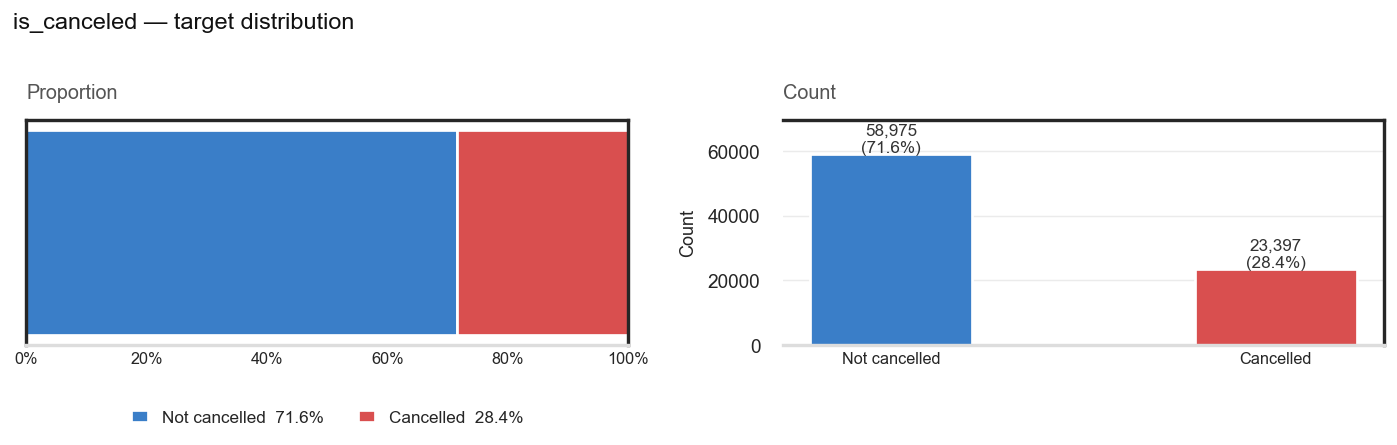

In [13]:
# ── Target distribution — HTML cards + bar chart ─────────────────────────
vc    = df[TARGET].value_counts().sort_index()
total = len(df)
not_c, canc = int(vc[0]), int(vc[1])
pct_c = canc / total

card_css = """
<style>
  .ov-wrap  { font-family: 'Segoe UI', 'DejaVu Sans', sans-serif; padding:6px 0 18px; }
  .ov-label { font-size:10px; font-weight:600; letter-spacing:.08em;
              text-transform:uppercase; color:#888; margin:0 0 6px; }
  .ov-title { font-size:17px; font-weight:600; color:#111; margin:0 0 14px; }
  .ov-grid  { display:grid; grid-template-columns:repeat(3,1fr); gap:10px; max-width:680px; }
  .ov-card  { background:#F6F7F8; border-radius:8px; padding:14px 18px; }
  .ov-clbl  { font-size:12px; color:#666; margin:0 0 4px; }
  .ov-cval  { font-size:24px; font-weight:600; margin:0; }
  .ov-csub  { font-size:12px; color:#999; margin:3px 0 0; }
</style>
"""
cards_html = f"""
{card_css}
<div class='ov-wrap'>
  <p class='ov-label'>Section 1 — Overview</p>
  <p class='ov-title'>Target distribution: is_canceled</p>
  <div class='ov-grid'>
    <div class='ov-card'>
      <p class='ov-clbl'>Total bookings</p>
      <p class='ov-cval' style='color:#111'>{total:,}</p>
    </div>
    <div class='ov-card'>
      <p class='ov-clbl'>Not cancelled</p>
      <p class='ov-cval' style='color:#3A7EC8'>{not_c:,}</p>
      <p class='ov-csub'>{not_c/total:.1%}</p>
    </div>
    <div class='ov-card'>
      <p class='ov-clbl'>Cancelled</p>
      <p class='ov-cval' style='color:#D94F4F'>{canc:,}</p>
      <p class='ov-csub'>{pct_c:.1%}</p>
    </div>
  </div>
</div>
"""
display(HTML(cards_html))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
fig.suptitle("is_canceled — target distribution", x=0.02, ha="left", fontsize=13, color="#111")

ax = axes[0]
ax.barh([""], [not_c/total], color=C_BLUE,  height=0.38, label=f"Not cancelled  {not_c/total:.1%}")
ax.barh([""], [canc/total],  color=C_RED,   height=0.38, left=[not_c/total], label=f"Cancelled  {pct_c:.1%}")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title("Proportion", fontsize=11, loc="left", color="#555")
ax.spines["bottom"].set_color("#DDD")
ax.tick_params(left=False, length=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=9.5, handlelength=1)

ax2 = axes[1]
bar_vals = [not_c, canc]
bar_cols = [C_BLUE, C_RED]
bars = ax2.bar(["Not cancelled", "Cancelled"], bar_vals, color=bar_cols, width=0.42, edgecolor="white")
for bar, val in zip(bars, bar_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + total*0.006,
             f"{val:,}\n({val/total:.1%})", ha="center", fontsize=9.5, color="#333")
ax2.set_ylim(0, max(bar_vals) * 1.18)
ax2.set_ylabel("Count", labelpad=6)
ax2.set_title("Count", fontsize=11, loc="left", color="#555")
ax2.spines["bottom"].set_color("#DDD")
ax2.tick_params(axis="x", length=0)
ax2.grid(axis="y", color="#EBEBEB"); ax2.set_axisbelow(True)
ax2.spines["left"].set_visible(False)

plt.tight_layout(pad=1.6)
plt.show()

**Target Distribution**

**28.4% of bookings are cancelled — roughly 1 in 4.** This is high enough to materially hurt revenue and occupancy planning.

The 72/28 class split is mild — models won't need heavy resampling, but track **F1 and AUC-ROC** over raw accuracy (accuracy is misleading at ≠50/50 splits). Establish this 28% as the business baseline: any intervention that moves it to ~20% is worth serious investment.

### 3. Main Insights

Each sub-section shows a chart of cancellation rate by category, followed by a short, sharp analysis of what it means and what to do about it.

#### 3.1 Hotel Type vs Cancellation Rate

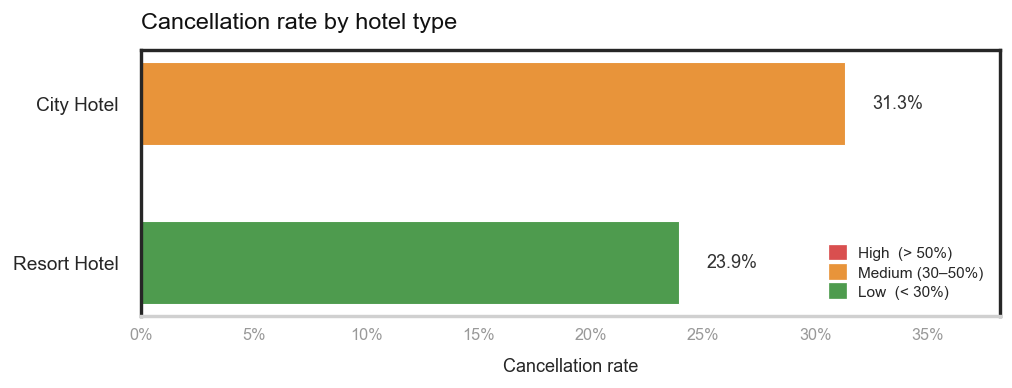

In [14]:
hbar("hotel", "Cancellation rate by hotel type")


| Hotel | Cancel rate |
|---|---|
| City Hotel | **31.3%** 🟠 |
| Resort Hotel | **23.9%** 🟢 |

A **7-point gap** between hotel types. City hotels attract more business travellers and last-minute bookings so plans change easily, alternatives are plentiful. Resort guests book holiday trips deliberately and are far more committed once a reservation is made.

### 3.2 Deposit Type vs Cancellation Rate

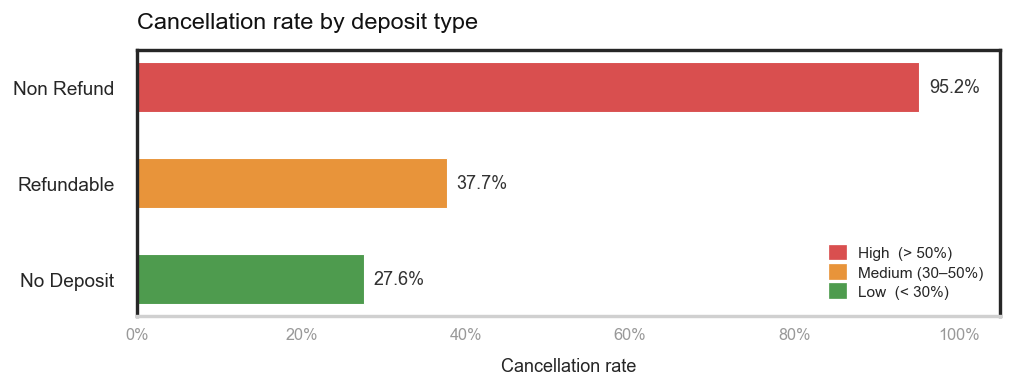

In [15]:
hbar("deposit_type", "Cancellation rate by deposit type")


**Insight — Deposit Type**

| Deposit Type | Cancel rate |
|---|---|
| Non Refund | **95.2%** 🔴 |
| Refundable | **37.7%** 🟠 |
| No Deposit | 27.6% 🟢 |

**3 key takeaways:**
1. **Non Refund bookings cancel at an extreme rate (95.2%)** — this is highly counterintuitive and likely signals a policy or data-quality issue rather than normal customer behavior.
2. **Refundable bookings cancel 1.4× more than No Deposit bookings** (37.7% vs 27.6%) — flexible policies appear to increase cancellation behavior.
3. **Deposit policy strongly influences cancellation outcomes** — making `deposit_type` one of the most important behavioral predictors in the dataset.
```

### 3.3 Market Segment vs Cancellation Rate

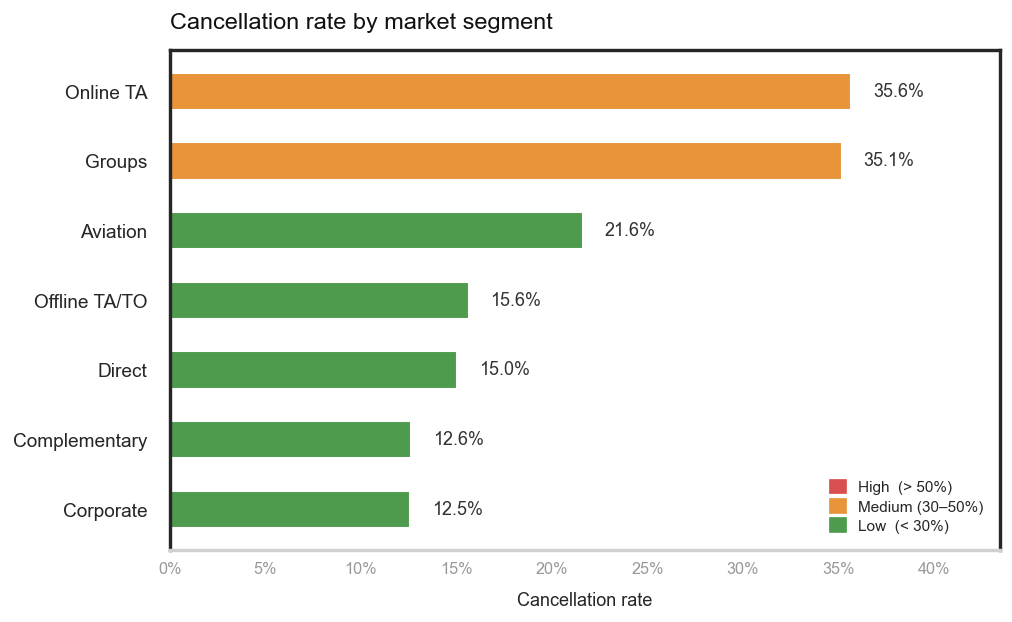

In [16]:
hbar("market_segment", "Cancellation rate by market segment", figsize=(8, 5))

**Insight — Market Segment**

| Segment | Cancel rate |
|---|---|
| Online TA | **35.6%** 🔴 |
| Groups | **35.1%** 🔴 |
| Aviation | 21.6% 🟢 |
| Offline TA/TO | 15.6% 🟢 |
| Direct | 15.0% 🟢 |
| Complementary | 12.6% 🟢 |
| Corporate | 12.5% 🟢 |

**3 key takeaways:**
1. **Online TA drives volume *and* cancellations** — at 35.6% it is the single biggest lever. Tightening the free-cancellation window from 24h → 48–72h is a low-friction, high-impact fix.
2. **Direct is 2.4× safer than Online TA** (15% vs 35.6%) — investing in a Book Direct campaign has a direct, measurable impact on cancellation rate.
3. **Corporate/Complementary anchor the bottom** (~12–13%) — these guests are deliberate and accountable; no intervention needed here.

### 3.4 Distribution Channel vs Cancellation Rate

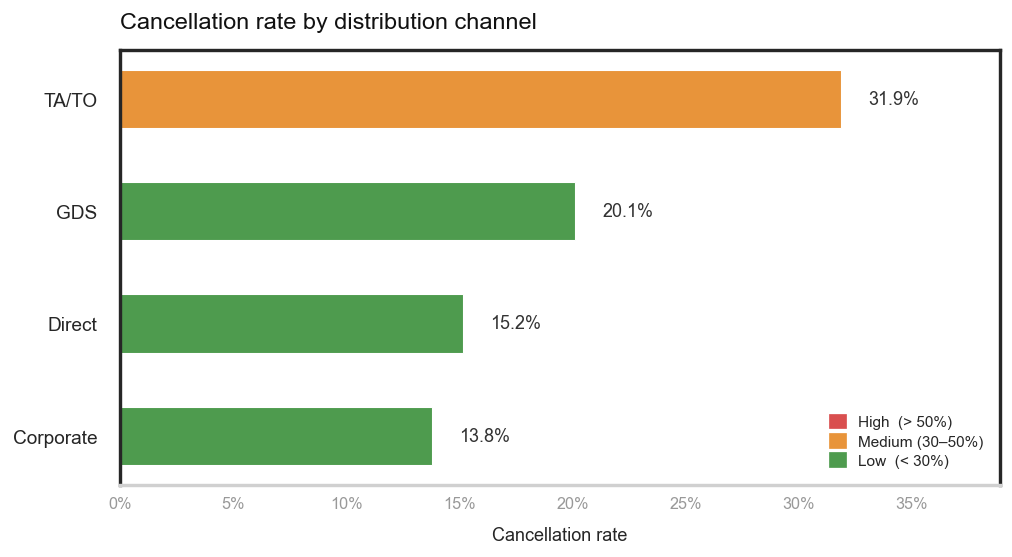

In [17]:
hbar("distribution_channel", "Cancellation rate by distribution channel", figsize=(8, 4.5))

**Insight — Distribution Channel**

| Channel | Cancel rate |
|---|---|
| TA/TO | **31.9%** 🟠 |
| GDS | 20.1% 🟢 |
| Direct | **15.2%** 🟢 |
| Corporate | 13.8% 🟢 |

Consistent with the market segment story: **travel-agent intermediated bookings cancel at 2× the rate of direct bookings.** GDS (used by corporate travel managers) is in the middle — managed travel has more process friction around cancellations.

**→ Action:** Run a "Book Direct" campaign with a clear value proposition (guaranteed best rate + a minor perk like early check-in). Even shifting 10% of TA/TO volume to Direct would measurably move the overall cancellation rate.

### 3.5 Customer Type vs Cancellation Rate

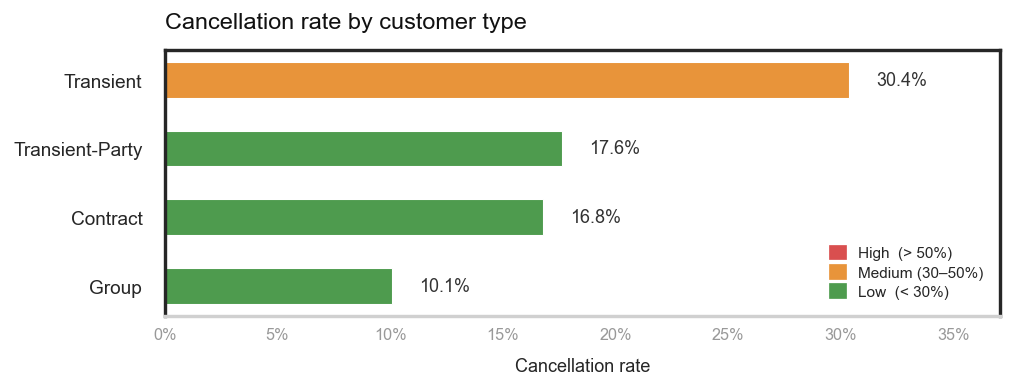

In [18]:
hbar("customer_type", "Cancellation rate by customer type")

**Insight — Customer Type**

| Customer type | Cancel rate |
|---|---|
| Transient | **30.4%** 🟠 |
| Transient-Party | 17.7% 🟢 |
| Contract | 16.8% 🟢 |
| Group | **10.1%** 🟢 |

**Groups barely cancel** — event commitments, deposits, and the social friction of group coordination make cancellation rare. Contract guests (corporate agreements) are similarly anchored. Transient guests are the main problem: no accountability, no prior relationship, easy to cancel.

**→ Action:** For Transient bookings, introduce pre-arrival engagement: a personalised confirmation email at T-7 days and T-48h reduces late cancellations by reinforcing commitment. Groups and Contracts are already low-risk — don't waste retention budget here.

### 3.6 Numerical Features vs Cancellation

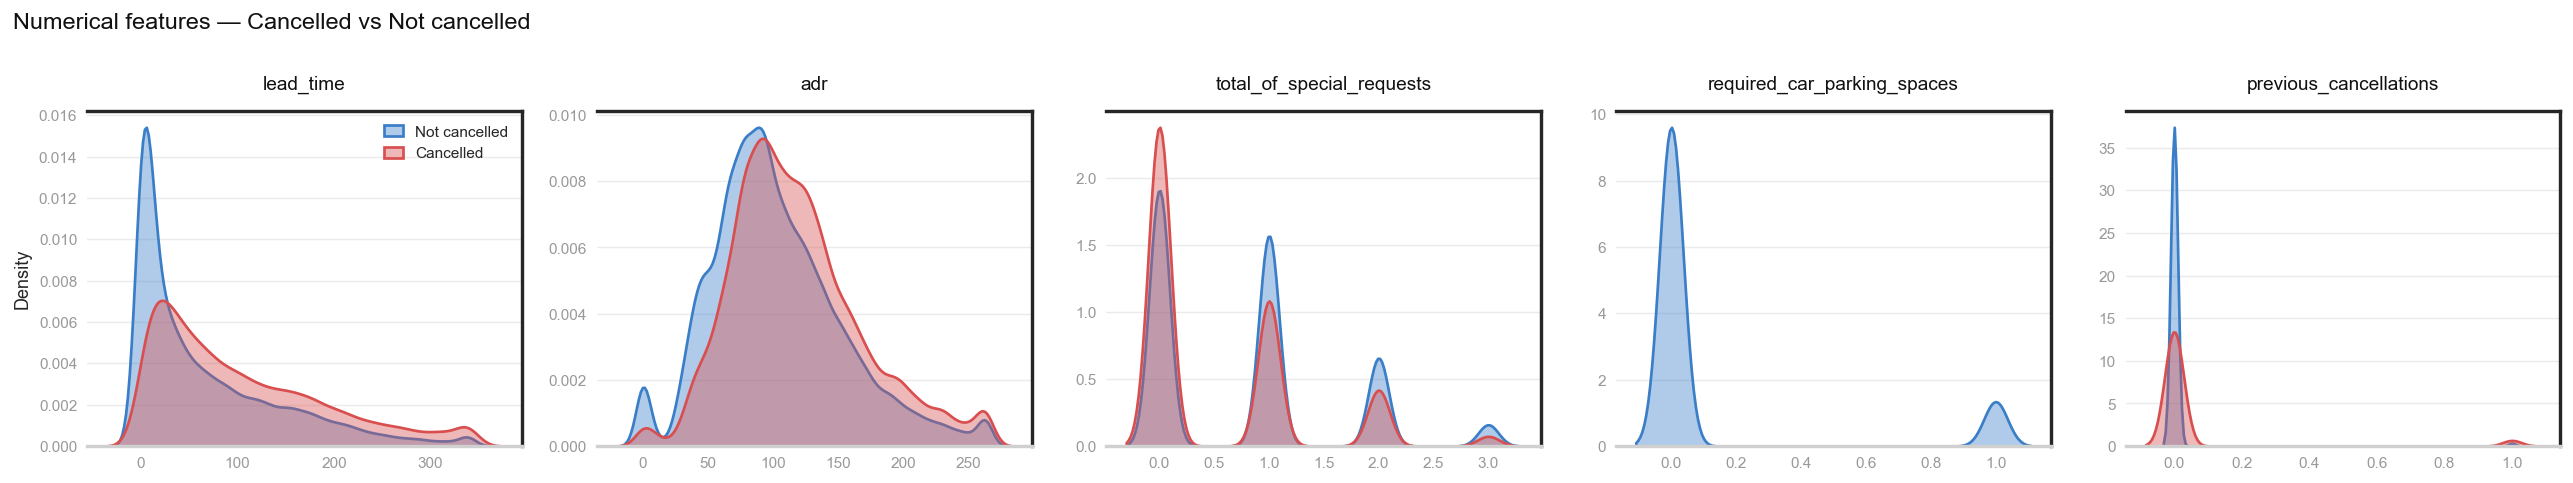

In [19]:
# ── 2.6 Numerical features — KDE density overlay ─────────────────────────────
num_cols = ["lead_time", "adr", "total_of_special_requests",
            "required_car_parking_spaces", "previous_cancellations"]

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 3.8))
fig.suptitle("Numerical features — Cancelled vs Not cancelled",
             x=0.01, ha="left", fontsize=13, color="#111", y=0.98)

for i, (ax, col) in enumerate(zip(axes, num_cols)):
    cap  = df[col].quantile(0.99)
    data = df.assign(**{col: df[col].clip(upper=cap)})
    sns.kdeplot(data=data[data[TARGET]==0][col], ax=ax, fill=True,
                color=C_BLUE, alpha=0.40, linewidth=1.5, label="Not cancelled")
    sns.kdeplot(data=data[data[TARGET]==1][col], ax=ax, fill=True,
                color=C_RED,  alpha=0.40, linewidth=1.5, label="Cancelled")
    ax.set_title(col, fontsize=10.5, color="#111")
    ax.set_xlabel(""); ax.set_ylabel("Density" if i == 0 else "")
    ax.spines["bottom"].set_color("#D0D0D0")
    ax.tick_params(colors="#999", length=2, labelsize=8.5)
    ax.grid(axis="y", color="#EBEBEB"); ax.set_axisbelow(True)
    ax.spines["left"].set_visible(False)
    if i == 0:
        ax.legend(fontsize=8.5, handlelength=1.2)

plt.tight_layout(pad=1.4)
plt.show()

**Insight — Numerical Features**

**Three signals stand out:**

| Feature | Not cancelled | Cancelled | Direction |
|---|---|---|---|
| `lead_time` (median) | 36 days | **79 days** | ↑ longer = more risk |
| `adr` (mean) | €103 | **€118** | ↑ higher rate = more risk |
| `total_special_requests` = 0 | 44.5% of guests | **60.2% of guests** | ↑ silence = more risk |

**Lead time** is the sharpest signal — cancelled bookings were made 2× further in advance. These guests are hedging: booking early to secure availability but staying open to better options.

**ADR** is also higher for cancelled bookings. Guests who book expensive rooms speculatively will cancel if they find a cheaper alternative.

**Special requests** are almost an inverted signal: guests who made even one request (pillow preference, dietary need) were far more likely to show up. Engagement at booking time = psychological commitment.

**→ Actions:**
- Use `lead_time` as the top-priority feature in your prediction model
- Flag high-lead-time + high-ADR + zero-requests bookings via OTA as your highest-risk cohort
- Add an optional preferences prompt to the booking flow — it's free to implement and functions as a commitment signal

### 4. Hypothesis Testing

All features visible in Section 2 are tested for statistical significance before promoting them to feature engineering.

**Significance threshold:** α = 0.05

### 4.1 Numerical Features — Mann-Whitney U Test

**Why Mann-Whitney U?** Numerical columns are heavily right-skewed (lead_time, ADR). Mann-Whitney makes no normality assumption and compares rank distributions directly — it's the right tool here.

- **H₀:** Distribution of the feature is *the same* for cancelled vs not-cancelled
- **H₁:** Distributions are *different* — reject H₀ if p-value < 0.05

In [20]:
ALPHA = 0.05
g1 = df[df[TARGET] == 1]
g0 = df[df[TARGET] == 0]

num_sources = {
    "lead_time"                     : "lead_time / is_short_lead",
    "required_car_parking_spaces"   : "required_car_parking_spaces",
    "total_of_special_requests"     : "total_of_special_requests",
    "previous_cancellations"        : "prior_cancel_rate",
    "previous_bookings_not_canceled": "prior_cancel_rate",
    "adr"                           : "adr_per_person",
}

# ── Run Mann-Whitney U for each numerical feature ────────────────────────────
num_results = []
for col, feat in num_sources.items():
    stat, p = stats.mannwhitneyu(g1[col], g0[col], alternative="two-sided")
    num_results.append({
        "source"    : col,
        "feeds_into": feat,
        "test"      : "Mann-Whitney U",
        "statistic" : f"{stat:.2e}",
        "p-value"   : f"{p:.3e}",
        "decision"  : "✅ KEEP" if p < ALPHA else "❌ DROP",
    })

num_hyp_df = pd.DataFrame(num_results)
num_hyp_df = pd.DataFrame(num_results)
print("=== 3.1 Numerical Features — Mann-Whitney U ===")
print(num_hyp_df)
print(f"\n✅ {(num_hyp_df['decision']=='✅ KEEP').sum()} / {len(num_hyp_df)} numerical features PASS")

=== 3.1 Numerical Features — Mann-Whitney U ===
                           source                   feeds_into            test statistic     p-value decision
0                       lead_time    lead_time / is_short_lead  Mann-Whitney U  9.00e+08   0.000e+00   ✅ KEEP
1     required_car_parking_spaces  required_car_parking_spaces  Mann-Whitney U  6.06e+08   0.000e+00   ✅ KEEP
2       total_of_special_requests    total_of_special_requests  Mann-Whitney U  5.76e+08   0.000e+00   ✅ KEEP
3          previous_cancellations            prior_cancel_rate  Mann-Whitney U  7.16e+08  5.536e-268   ✅ KEEP
4  previous_bookings_not_canceled            prior_cancel_rate  Mann-Whitney U  6.56e+08  1.747e-215   ✅ KEEP
5                             adr               adr_per_person  Mann-Whitney U  8.12e+08   0.000e+00   ✅ KEEP

✅ 6 / 6 numerical features PASS


### 4.2 Categorical Features — Chi-Square Test

**Why Chi-Square?** Tests whether cancellation proportions differ significantly across categories using a contingency table — the standard test for categorical independence.

- **H₀:** Feature is *independent* of `is_canceled`
- **H₁:** They are *not independent* — reject H₀ if p-value < 0.05

In [21]:
cat_sources = ["hotel", "deposit_type", "market_segment",
               "distribution_channel", "customer_type"]

cat_results = []
for col in cat_sources:
    ct      = pd.crosstab(df[col], df[TARGET])
    _, p, _, _ = stats.chi2_contingency(ct)
    cat_results.append({
        "source"    : col,
        "feeds_into": col,
        "test"      : "Chi-Square",
        "p-value"   : f"{p:.3e}",
        "decision"  : "✅ KEEP" if p < ALPHA else "❌ DROP",
    })

cat_hyp_df = pd.DataFrame(cat_results)
print("=== 3.2 Categorical Features — Chi-Square ===")
print(cat_hyp_df)
hyp_df = pd.concat([num_hyp_df, cat_hyp_df], ignore_index=True)
n_pass = (hyp_df["decision"] == "✅ KEEP").sum()
n_fail = (hyp_df["decision"] == "❌ DROP").sum()
print(f"\n✅ {n_pass} features PASS  |  ❌ {n_fail} FAIL")
print("All source features are statistically significant — proceed to feature engineering.")

=== 3.2 Categorical Features — Chi-Square ===
                 source            feeds_into        test     p-value decision
0                 hotel                 hotel  Chi-Square  3.073e-116   ✅ KEEP
1          deposit_type          deposit_type  Chi-Square   0.000e+00   ✅ KEEP
2        market_segment        market_segment  Chi-Square   0.000e+00   ✅ KEEP
3  distribution_channel  distribution_channel  Chi-Square   0.000e+00   ✅ KEEP
4         customer_type         customer_type  Chi-Square  1.902e-199   ✅ KEEP

✅ 11 features PASS  |  ❌ 0 FAIL
All source features are statistically significant — proceed to feature engineering.


### 4.3 EDA Summary — Feature Shortlist

| Feature | Type | Signal strength | Modelling note |
|---|---|---|---|
| `deposit_type` | Cat | 🔴 Very high (verify leakage!) | Confirm availability at booking time |
| `lead_time` | Num | 🔴 High | Top numeric predictor |
| `market_segment` | Cat | 🔴 High | Drop "Undefined" rows |
| `total_special_requests` | Num | 🔴 High | Strong commitment proxy |
| `required_car_parking_spaces` | Num | 🟠 High (binary signal) | 0% cancel when > 0 |
| `distribution_channel` | Cat | 🟠 Medium-high | Collinear with market_segment |
| `hotel` | Cat | 🟠 Medium | Consider separate models per type |
| `customer_type` | Cat | 🟠 Medium | — |
| `adr` | Num | 🟢 Medium | Engineer adr_per_person |
| `previous_cancellations` | Num | 🟢 Medium | Engineer prior_cancel_rate |

**Modelling recommendations:**
- Use a **time-based train/test split** (train 2015–2016, test 2017) — random split leaks temporal trend
- Check `deposit_type = Non Refund` for data leakage before including
- Ensemble methods (XGBoost, LightGBM) will outperform logistic regression given the non-linear lead_time relationship
- Cancellation rate is rising year-over-year (+11pp from 2015→2017) — include `arrival_date_year` or a trend feature

### 5.1 Correllation Heatmap

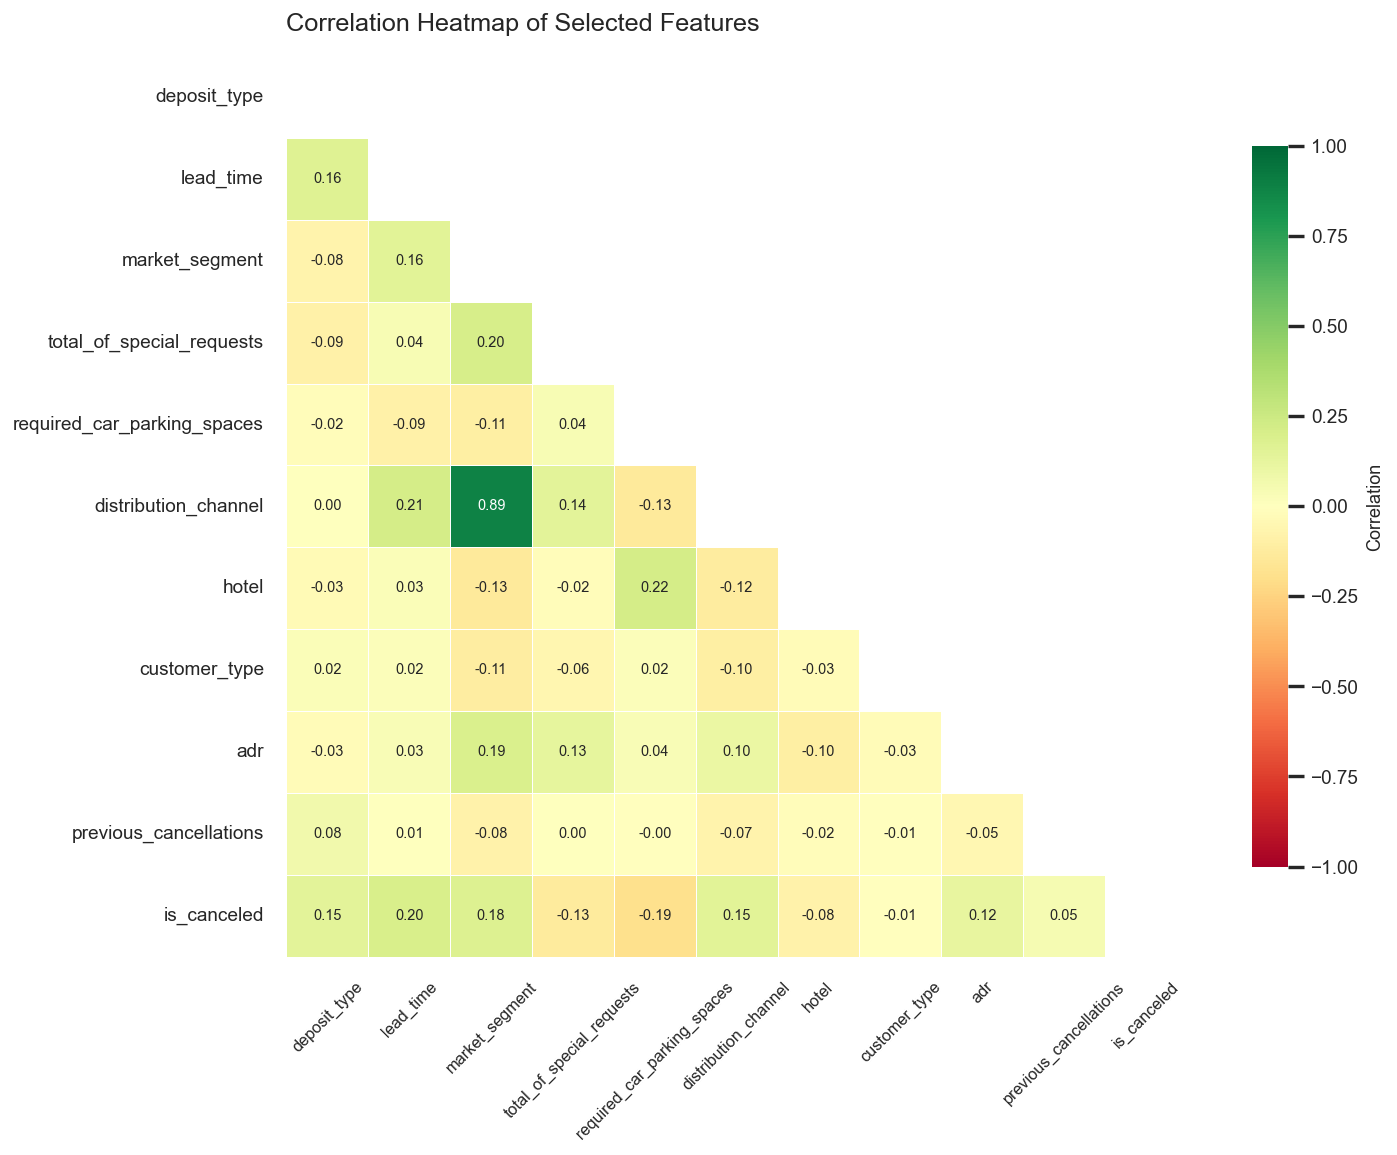

In [22]:

# Features selected from EDA insights
features = [
    "deposit_type",
    "lead_time",
    "market_segment",
    "total_of_special_requests",
    "required_car_parking_spaces",
    "distribution_channel",
    "hotel",
    "customer_type",
    "adr",
    "previous_cancellations",
    "is_canceled"
]

# Create temporary dataframe
heatmap_df = df[features].copy()

# Encode categorical variables
cat_cols = [
    "deposit_type",
    "market_segment",
    "distribution_channel",
    "hotel",
    "customer_type"
]

for col in cat_cols:
    heatmap_df[col] = heatmap_df[col].astype("category").cat.codes

# Correlation matrix
corr_matrix = heatmap_df.corr()

# Upper triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    mask = mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    annot_kws={"size": 8},
    cbar_kws={"label": "Correlation", "shrink": 0.8}
)

ax.set_title(
    "Correlation Heatmap of Selected Features",
    fontsize=14,
    pad=14,
    loc="left"
)

ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

**Insight — Heatmap**
- market_segment and distribution_channel have a very strong correlation (0.89), indicating potential multicollinearity and overlapping information.

- lead_time has the strongest positive relationship with cancellations (0.20), suggesting that bookings made further in advance are more likely to be canceled.

- required_car_parking_spaces and total_of_special_requests are negatively correlated with cancellations, implying that more committed guests are less likely to cancel.




### 5.2 Cancellation Heatmap — Market Segment vs Cancellation

Shows **how** cancellation rates vary across different market segments, helping identify the highest-risk booking channels.

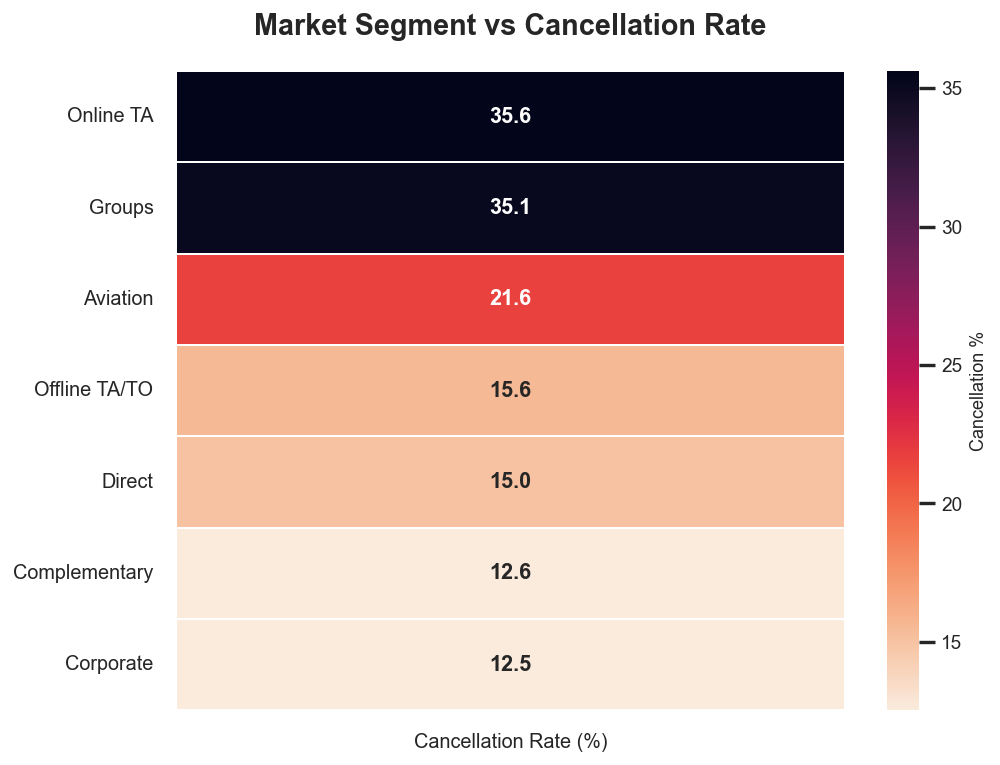

In [23]:
# Create cancellation rate table
cancel_rate_df = (
    df.groupby('market_segment')['is_canceled']
    .mean()
    .mul(100)
    .reset_index()
)

# Sort values
cancel_rate_df = cancel_rate_df.sort_values(
    by='is_canceled',
    ascending=False
)

# Set market segment as index
cancel_rate_df = cancel_rate_df.set_index('market_segment')

# Rename column
cancel_rate_df.columns = ['Cancellation Rate (%)']

# Plot
sns.set_style("white")

plt.figure(figsize=(8,6))

sns.heatmap(
    cancel_rate_df,
    annot=True,
    fmt=".1f",
    cmap="rocket_r",
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Cancellation %'},
    annot_kws={"size":12, "weight":"bold"}
)

plt.title(
    "Market Segment vs Cancellation Rate",
    fontsize=16,
    weight='bold',
    pad=20
)

plt.xlabel("")
plt.ylabel("")

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

**Insight — Heatmap**

- **Online TA and Groups** segments have the highest cancellation rates, making them the riskiest booking channels.
- **Corporate and Complementary** bookings show the lowest cancellation rates, indicating more stable customer behavior.
- **Market** segment has a strong influence on booking cancellation patterns and is an important feature for predictive modeling.